In [94]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pyAgrum as gum
import pyAgrum.lib.notebook as gnb


# Question 1

### 1a) 
**To assess the measurement statistics for each sample I first load the CVS file and compute a mean measure of central tendency and a standard deviation measure of spread.**

using python pandas i compute the mean and stdev

In [97]:
fast_made = pd.read_csv("3d_printing.csv")
print(fast_made.head(3))          # Successfully loaded CSV in python printing first 3 rows for observation

temp_mean = fast_made['Temperature'].mean()      # compute the mean
temp_std = fast_made['Temperature'].std()        # compute the stdev



print(f'\nThe mean printing temperature is {temp_mean:.2f}, with a standard deviaiton of {temp_std:.2f}.')

  FlowRate  Temperature Robustness
0      Low          193   Moderate
1      Low          218     Strong
2      Low          220     Strong

The mean printing temperature is 210.97, with a standard deviaiton of 16.80.


### 1b)
**I begin this section of the analysis by seperating the temperature into 3 distinct categories: Low, Medium and High**

Through the def statement,  i use a nested loop to automate the process of assigning a temperature category to the recorded temperature.

I then manually assess the df to ensure the categries match appropriately

In [99]:
def grouped_temp(Temperature):
    if Temperature < 200:         
        return "Low"
    elif 200 <= Temperature <= 220:
        return "Medium"
    else:
        return "High"

fast_made['TemperatureCategory'] = fast_made['Temperature'].apply(grouped_temp)  
fast_made

,FlowRate,Temperature,Robustness,TemperatureCategory
0,Low,193,Moderate,Low
1,Low,218,Strong,Medium
2,Low,220,Strong,Medium
3,High,185,Weak,Low
4,High,217,Moderate,Medium
5,High,231,Strong,High
6,Low,196,Moderate,Low
7,Low,210,Strong,Medium
8,Low,215,Strong,Medium
9,High,191,Weak,Low


**I then compute the frequency of each category**

I group temperatures into the three groups: low, medium and high and count their occurances. these frequencies are then normalised by dividing each count by the total number of temperature observations allowing for the probability distribution for P(TemperatureCategory)

In [101]:
low_temp = (fast_made['TemperatureCategory'] == 'Low').sum()
med_temp = (fast_made['TemperatureCategory'] == 'Medium').sum()
high_temp = (fast_made['TemperatureCategory'] == 'High').sum()

total_temp_freq = low_temp + med_temp + high_temp

low_freq = low_temp / total_temp_freq
med_freq = med_temp / total_temp_freq
high_freq = high_temp / total_temp_freq

p_tempcat_table = {'Low': low_freq, 'Medium' : med_freq, 'High' : high_freq}

print(f'The probability table for P(TemperatureCategory) is:\n', p_tempcat_table)

The probability table for P(TemperatureCategory) is:
 {'Low': 0.3333333333333333, 'Medium': 0.4, 'High': 0.26666666666666666}


### 1c)

**I use linear regression analysis to predict robustness given temperature category and flow rate reporting intercept, coefficients and MSE**

I perform linear regression to predict robustness based on temperature category and flow rate. I encode categorical variables using one hot encoding and map the robust levels to numerical values to then fit the regression model. i report theintercept, coefficients and mean squared error and visualise through a scatterplot to show the predicted versus actual robustness values.

The largely negative intercept and low MSE suggests a poor fit of the model. Some coefficients suchas Low high temperature have a stronger effect, significantly decreasing robustness.

The intercept is: -4.355663981501257
The coefficients for the model are: [ 0.02553002 -0.5896994   0.02470687  0.51273045]
The mean squared error for the model is: 0.11362315106882992


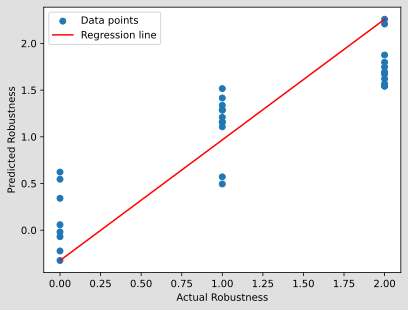

In [104]:
fastmade_dummies = fast_made

fastmade_dummies = pd.get_dummies(fastmade_dummies, columns = ['TemperatureCategory', 'FlowRate'], drop_first = True)

map_robustness = {'Weak' : 0, 'Moderate' : 1, 'Strong' : 2}
fastmade_dummies['Robustness'] = fastmade_dummies['Robustness'].map(map_robustness)

X = fastmade_dummies.drop(columns = ['Robustness'])
y = fastmade_dummies['Robustness']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

MSE = mean_squared_error(y, y_pred)

print('The intercept is:', model.intercept_)
print('The coefficients for the model are:', model.coef_)
print('The mean squared error for the model is:', MSE)

plt.scatter(y, y_pred, label="Data points")
plt.plot([min(y), max(y)], [min(y_pred), max(y_pred)], color='red', label="Regression line")
plt.xlabel("Actual Robustness")
plt.ylabel("Predicted Robustness")
plt.legend()
plt.show()


# Question 2

### 2a)
**I begin this section of the analysis by loading the dataset, calculating the sum of values within the csv file and working out P(FlowRate)**

I work out the probability P(Flowrate) by summing occurances of high an dlow flow rates in the dataset and appluying empirical probability formula. I also check for null values to ensure the flowrate only contains expected categories. My sumary confirms lisas calculations.

In [107]:
high_flowrate = (fast_made['FlowRate'] == 'High').sum()
low_flowrate = (fast_made['FlowRate'] == 'Low').sum()
total_samples = high_flowrate + low_flowrate

# applying the empirical probability formula

p_flowrate = high_flowrate / total_samples

print('\nThe amount of null values for each column are:\n', fast_made.isnull().sum(), '\nAnd the unique values in "flowrate" are consistent being:', fast_made['FlowRate'].unique())  
print(f'\nLisas study returned a P(FlowRate) of 0.5, this study confirms lisas calculations as correct as I also return a P(FlowRate) of:', p_flowrate)



The amount of null values for each column are:
 FlowRate               0
Temperature            0
Robustness             0
TemperatureCategory    0
dtype: int64 
And the unique values in "flowrate" are consistent being: ['Low' 'High']

Lisas study returned a P(FlowRate) of 0.5, this study confirms lisas calculations as correct as I also return a P(FlowRate) of: 0.5


### 2b)
**Within this section i now compute the probability of robustness (P(Robustness)) and the conditional probability of robustness given temperature and flowrate (P(Robustness | Temperature, FlowRate)**

The marginal probability is calculated by counting each robustness category and normalizing over the total. I use a bar chart for visualisation 
I then compute the conditional probability b by grouping the data, normalizing within each conditn. I use a stacked barchart for visualisation and add a count of the distributions in a dataframe below  


The counts of weak robustness are 8, at a proportion of: 26.67%
The counts of moderate robustness are, 11, at a proportion of, 36.67%
The counts of strong robustness are, 11, at a proportion of, 36.67%


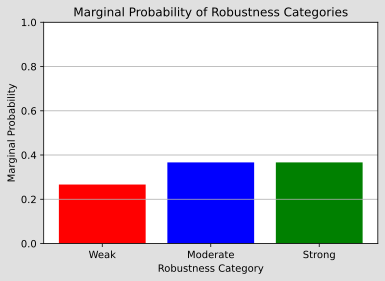

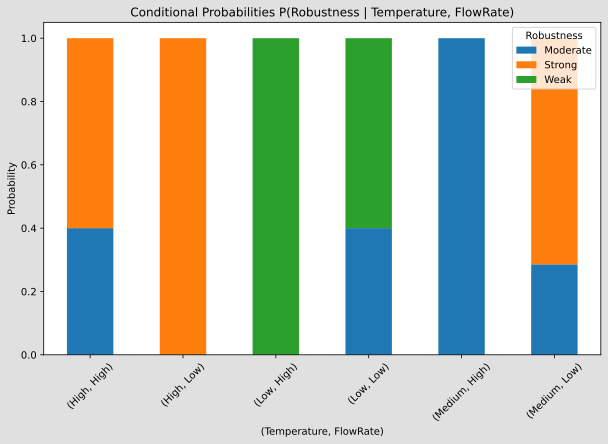

Robustness                    Moderate    Strong  Weak
TemperatureCategory FlowRate                          
High                High      0.400000  0.600000   0.0
                    Low       0.000000  1.000000   0.0
Low                 High      0.000000  0.000000   1.0
                    Low       0.400000  0.000000   0.6
Medium              High      1.000000  0.000000   0.0
                    Low       0.285714  0.714286   0.0

In [109]:
# first work out the marginal probabilities P(Robustness)
weak_robus = (fast_made['Robustness'] == 'Weak').sum()
mod_robus = (fast_made['Robustness'] == 'Moderate').sum()
strong_robus = (fast_made['Robustness'] == 'Strong').sum()

total_robus = weak_robus + mod_robus + strong_robus       

p_weak = weak_robus / total_robus            # take the counts and divide it over the sum
p_mod = mod_robus / total_robus
p_strong = strong_robus / total_robus

print(f"The counts of weak robustness are {weak_robus}, at a proportion of: {p_weak:.2%}")
print(f"The counts of moderate robustness are, {mod_robus}, at a proportion of, {p_mod:.2%}")
print(f"The counts of strong robustness are, {strong_robus}, at a proportion of, {p_strong:.2%}")

marginal_prob = {'Weak': p_weak, 'Moderate' : p_mod, 'Strong' : p_strong}     #initialise dict for barchart

marginal_prob_df = pd.DataFrame(list(marginal_prob.items()), columns=["Robustness", "P(Robustness)"])  #df for visualisation

plt.figure(figsize=(6, 4))
plt.bar(marginal_prob_df["Robustness"], marginal_prob_df["P(Robustness)"], color=['red', 'blue', 'green'])
plt.xlabel("Robustness Category")
plt.ylabel("Marginal Probability")
plt.title("Marginal Probability of Robustness Categories")
plt.ylim(0, 1)
plt.grid(axis='y')

plt.show()


group_uni = fast_made.groupby(['TemperatureCategory', 'FlowRate', 'Robustness']).size().unstack(fill_value = 0)   # unstack to reshape data for robustness coloumn
cond_prob = group_uni.div(group_uni.sum(axis = 1), axis = 0)

cond_prob_df = cond_prob.reset_index()


cond_prob.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Conditional Probabilities P(Robustness | Temperature, FlowRate)')
plt.xlabel('(Temperature, FlowRate)')
plt.ylabel('Probability')
plt.xticks(rotation=45)
plt.legend(title='Robustness')
plt.show()

cond_prob


### 2c)
**I compute P(Breaks | PassesQA)**
using the law of total probability i manually sum the weighted probabilities of passing QA for all robust levels. 
I then compute the joint probabilities of passing both QA an dbreakingnormalisign by P(PassesQA) to get the finakl conditional probability

In [111]:
weakly_robust = 0.3     # prob pass P(PassQA | Weak)
moderate_robust = 0.6
strongly_robust = 0.9

undiscarded_weakly_robust = 0.5    #prob break if not discard P(Breaks | Weak, PassQA)
undiscarded_moderately_robust = 0.1
undiscarded_strongly_robust = 0.01

print(p_weak)   # PRIORS robustness
print(p_mod)
print(p_strong)


p_pass_qa = (weakly_robust * p_weak) + (moderate_robust * p_mod) + (strongly_robust * p_strong)

#conditional prob
p_break_given_pass = (undiscarded_weakly_robust * weakly_robust *
                p_weak) + (undiscarded_moderately_robust *
                           moderate_robust * p_mod) + (undiscarded_strongly_robust 
                            * strongly_robust * p_strong) 
cond_prob_breaks_given_pass = p_break_given_pass / p_pass_qa
print(f"The conditional probability the product breaks given it passes Quality Assurance is {cond_prob_breaks_given_pass:.2%}")

0.26666666666666666
0.36666666666666664
0.36666666666666664
The conditional probability the product breaks given it passes Quality Assurance is 10.37%


### 2d)
**I compute P(Weak | Breaks, PassesQA)**

I use bayes theorem to compute P(Weak | Breaks, Passes QA). I begin by working out P(Weak | PassQA) with the conditional probability formula. Next i update the probability considerign breakage given that the product passed QA, normalising by P(Breaks | Passes QA)

In [113]:

p_weak_given_pass = (weakly_robust * p_weak) / p_pass_qa    #p(weak | passQA)

cond_prob_weak_given_breaks_pass = (undiscarded_weakly_robust * p_weak_given_pass) / cond_prob_breaks_given_pass  #P(weak | breaks,passedQA)
print(f"The probability the product is weak given the conditional probability it breaks and passes quality assurance is {cond_prob_weak_given_breaks_pass:.2%}")

The probability the product is weak given the conditional probability it breaks and passes quality assurance is 61.26%


# Question 3

### 3a)
**I implement a Bayesian Network using pyArgum and compute the marginal probability that a product breaks**

I implemented a Bayesian network to represent fastmades’s production and quality assurance process. I define five variables: FlowRate, TemperatureCategory, Robustness, QA (Quality Assurance), and Breaks

I structured the networwithng directed arcto visualise dependencies between  ** **FlowRate and TemperatureCateg**y** influen** **Robustn**s**.  
- **Robustness** affects both **QA outcomes** and **whether a product breaks**- **QA results** also influence **Breaks** 

`pyargum` is usef for visualisationork.  


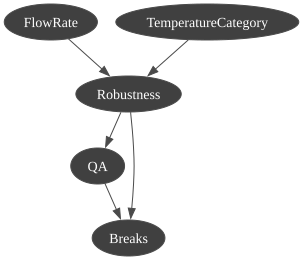

In [116]:

# Bayesian network
bn_fm = gum.BayesNet('FastMade')

# defining my variables
flow = bn_fm.add(gum.LabelizedVariable('FlowRate', 'Flow Rate', ['Low', 'High']))
tempcat = bn_fm.add(gum.LabelizedVariable('TemperatureCategory', 'Temperature Category', ['Low', 'Medium', 'High']))
robustness = bn_fm.add(gum.LabelizedVariable('Robustness', 'Robustness Level', ['Moderate', 'Strong', 'Weak']))
QA = bn_fm.add(gum.LabelizedVariable('QA', 'Quality Assurance', ['Pass', 'Fail']))
breaks = bn_fm.add(gum.LabelizedVariable('Breaks', 'Breaks', ['Yes', 'No']))

bn_fm.addArc(tempcat, robustness)
bn_fm.addArc(flow, robustness)
bn_fm.addArc(robustness, QA)
bn_fm.addArc(robustness, breaks)
bn_fm.addArc(QA, breaks)

gnb.showBN(bn_fm)

In [117]:
# marginal prob tempcat
bn_fm.cpt(tempcat).fillWith([0.333, 0.4, 0.267])

#marginal p flow
bn_fm.cpt(flow).fillWith([0.5, 0.5])

#conditional probability for Quality assurance given robustness
bn_fm.cpt(QA)[{'Robustness': 'Weak'}] = [0.3, 0.7]  
bn_fm.cpt(QA)[{'Robustness': 'Moderate'}] = [0.6, 0.4]  
bn_fm.cpt(QA)[{'Robustness': 'Strong'}] = [0.9, 0.1]  

# cond probability it breaks given qa and robustness
bn_fm.cpt(breaks)[{'QA': 'Pass', 'Robustness': 'Weak'}] = [0.5, 0.5]  
bn_fm.cpt(breaks)[{'QA': 'Pass', 'Robustness': 'Moderate'}] = [0.1, 0.9] 
bn_fm.cpt(breaks)[{'QA': 'Pass', 'Robustness': 'Strong'}] = [0.01, 0.99] 
bn_fm.cpt(breaks)[{'QA': 'Fail', 'Robustness': 'Weak'}] = [0.01, 0.99]  
bn_fm.cpt(breaks)[{'QA': 'Fail', 'Robustness': 'Moderate'}] = [0.01, 0.99]
bn_fm.cpt(breaks)[{'QA': 'Fail', 'Robustness': 'Strong'}] = [0.01, 0.99]
# conditional prob for robustness given temperature category and flowrate

bn_fm.cpt(robustness)[{'FlowRate':'High', 'TemperatureCategory':'High'}] = [0.0, 0.4, 0.6]
bn_fm.cpt(robustness)[{'FlowRate':'Low', 'TemperatureCategory':'High'}] = [0.01, 0.01, 0.98]
bn_fm.cpt(robustness)[{'FlowRate':'High', 'TemperatureCategory':'Low'}] = [0.98, 0.01, 0.01]
bn_fm.cpt(robustness)[{'FlowRate':'Low', 'TemperatureCategory':'Low'}] = [0.6, 0.4, 0.0]
bn_fm.cpt(robustness)[{'FlowRate':'High', 'TemperatureCategory':'Medium'}] = [0.01, 0.98, 0.01]
bn_fm.cpt(robustness)[{'FlowRate':'Low', 'TemperatureCategory':'Medium'}] = [0.0, 0.2857, 0.7143]

gnb.sideBySide(bn_fm.cpt(QA), bn_fm.cpt(tempcat), bn_fm.cpt(flow))
gnb.sideBySide(bn_fm.cpt(breaks))
gnb.sideBySide(bn_fm.cpt(robustness))

In [118]:
inference_engine = gum.LazyPropagation(bn_fm)
inference_engine.makeInference()

p_breaks = inference_engine.posterior(breaks)  # P(Breaks) 
print(f"The marginal probability a product breaks (P(Breaks)) is: {p_breaks[0]}")


The marginal probability a product breaks (P(Breaks)) is: 0.076931755


**I visualise the result**

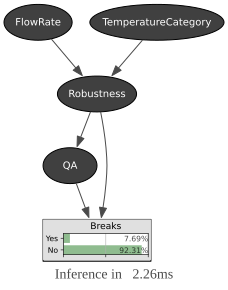

In [120]:
ie = gum.VariableElimination(bn_fm)    # i visualise this result through the inference engine
ie.makeInference()
gnb.showInference(bn_fm, evs={}, targets=[breaks])


### 3b)
**Here i work out the probability a product with a high flow rate breaks was strongly robust P(Strong | Breaks, High flow rate)**

I used Bayesian inference to compute P(Strong|Breaks,High Flow Rate). First, I set the evidence that a product has broken and was produced with a high flow rate. Then, I performed inference for the posterior probability distribution over Robustness. i work out the probability corresponding to the Strong robustness level and visualise the result.  


In [122]:
inference_engine.setEvidence({'Breaks': 'Yes', 'FlowRate' : 'High'})
inference_engine.makeInference()

pos_robustness = inference_engine.posterior(bn_fm.idFromName('Robustness'))
#p_strong_given_breaks_high = pos_robustness[pos_robustness.variable().index('Strong')]
#p_strong_given_breaks_high = pos_robustness[2]
p_strong_given_breaks_high = pos_robustness[gum.LabelizedVariable('Robustness', '', ['Moderate', 'Strong', 'Weak']).index('Strong')]


print(f"P(Strong | Breaks, High Flow Rate) = {p_strong_given_breaks_high:.4f}")


P(Strong | Breaks, High Flow Rate) = 0.0957


**I visualise the result**

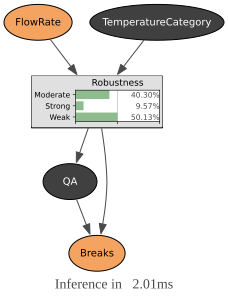

In [124]:
gnb.showInference(bn_fm, evs={"FlowRate": "High", "Breaks": "Yes"}, targets=["Robustness"])       # here is simply visualise through the inference engine


I calculated p(Strong | Breaks, High FlowRate) using conditional probabilities. First, I found the distribution of robustness levels for high flow rate. Then, I used the law of total probability to determine p(Breaks). Finally, I computed the conditional probability of strong robustness given that a high flow rate product has broken.  


In [126]:
p_pass_weak = 0.3
p_pass_mod = 0.6
p_pass_strong = 0.9

p_break_weak = 0.5
p_break_mod = 0.1
p_break_strong = 0.01

#print(p_weak)   # PRIORS robustness
#print(p_mod)
#print(p_strong)

total_high_flow = fast_made[fast_made['FlowRate'] == 'High'].shape[0]

weak_high_flow = fast_made[(fast_made["FlowRate"] == "High") & (fast_made["Robustness"] == "Weak")].shape[0]
moderate_high_flow = fast_made[(fast_made["FlowRate"] == "High") & (fast_made["Robustness"] == "Moderate")].shape[0]
strong_high_flow = fast_made[(fast_made["FlowRate"] == "High") & (fast_made["Robustness"] == "Strong")].shape[0]

p_weak_given_high = weak_high_flow / total_high_flow
p_moderate_given_high = moderate_high_flow / total_high_flow
p_strong_given_high = strong_high_flow / total_high_flow

print("P(Weak | High FlowRate):", p_weak_given_high)
print("P(Moderate | High FlowRate):", p_moderate_given_high)
print("P(Strong | High FlowRate):", p_strong_given_high)

#print(strong_high_flow + moderate_high_flow + weak_high_flow)

pr_break = (p_weak_given_high * p_pass_weak 
            * p_break_weak) + (p_moderate_given_high * 
                               p_pass_mod * p_break_mod) + (
    p_strong_given_high * p_pass_strong * p_break_strong)

pr_strong_break = (p_pass_strong * p_break_strong)

pr_strong_break_highflow = pr_strong_break / pr_break

print(f" The probability a product with a high flow rate that breaks was strongly robust is {pr_strong_break_highflow:.2%}")

print(weak_high_flow, moderate_high_flow, strong_high_flow)
print(weak_high_flow + moderate_high_flow + strong_high_flow)


P(Weak | High FlowRate): 0.3333333333333333
P(Moderate | High FlowRate): 0.4666666666666667
P(Strong | High FlowRate): 0.2
 The probability a product with a high flow rate that breaks was strongly robust is 11.28%
5 7 3
15


### 3c)
**Here i work out the relative risk of products breaking if produced at low vs high temperature**

I used Bayesian inference to compute p(Breaks | Low Temperature) and p(Breaks | High Temperature). By setting the temperature category as evidence and performing inference, I get the posterior probability of a product breaking. I then calculated the relative risk by dividing p(Breaks | Low Temperature) by p(Breaks | High Temperature).  


In [129]:
inference_engine = gum.LazyPropagation(bn_fm)

def get_p_break_given_temperature(temp_category):
    inference_engine.setEvidence({"TemperatureCategory": temp_category})  
    inference_engine.makeInference()
    posterior_breaks = inference_engine.posterior(bn_fm.idFromName("Breaks"))  # I only consider the posterior distribution
    return posterior_breaks[0]      # returns p breaks = yes

p_break_given_low = get_p_break_given_temperature("Low")
p_break_given_high = get_p_break_given_temperature("High")
    
rr = p_break_given_low / p_break_given_high

print(f"P(Breaks | Low Temperature) = {p_break_given_low:.4f}")
print(f"P(Breaks | High Temperature) = {p_break_given_high:.4f}")
print(f"Relative risk = {rr:.4f}")

P(Breaks | Low Temperature) = 0.0534
P(Breaks | High Temperature) = 0.1264
Relative risk = 0.4224


**I visualise with the inference diagram**

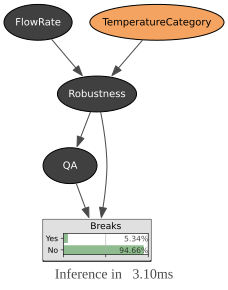

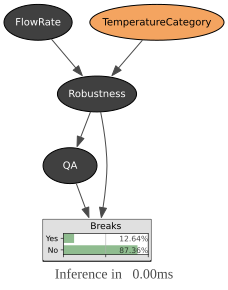

In [131]:
gnb.showInference(bn_fm, evs={"TemperatureCategory": "Low"}, targets=["Breaks"])
gnb.showInference(bn_fm, evs={"TemperatureCategory": "High"}, targets=["Breaks"])


# Question 4

### 4a)
**I draw an influence diagram to represent Lisas situation**

I create an influence diagram for lisas decision-making process regarding quality assurance. The diagram includes chance nodes for FlowRate, TemperatureCategory, Robustness, Passes_QA, and Breaks, a decision node for QA, and a utility node for Profit. Arcs show dependencies, such as how QA influences product robustness and breakage, ultimately affecting profit. I visualized the diagram using pyAgrum.  


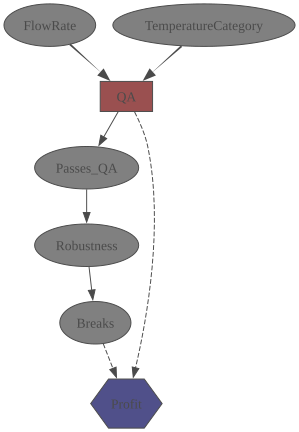

In [134]:
id = gum.InfluenceDiagram()

flow = id.addChanceNode(gum.LabelizedVariable('FlowRate', 'Flow Rate', ['Low', 'High']))
temp = id.addChanceNode(gum.LabelizedVariable('TemperatureCategory', 'Temperature Category', ['Low', 'Medium', 'High']))
robustness = id.addChanceNode(gum.LabelizedVariable('Robustness', 'Robustness Level', ['Weak', 'Moderate', 'Strong']))
QA_decision = id.addDecisionNode(gum.LabelizedVariable('QA', 'Quality Assurance', ['Keep', 'Drop']))
breaks = id.addChanceNode(gum.LabelizedVariable('Breaks', 'Breaks', ['Yes', 'No']))
passes_qa = id.addChanceNode(gum.LabelizedVariable('Passes_QA', 'Passes QA', ['Yes', 'No']))


profit = id.addUtilityNode(gum.LabelizedVariable('Profit', 'Profit', 1))

id.addArc(flow, QA_decision)  
id.addArc(temp, QA_decision) 
id.addArc(QA_decision, passes_qa)
id.addArc(passes_qa, robustness)
id.addArc(robustness, breaks)  
id.addArc(breaks, profit)  
id.addArc(QA_decision, profit)

#id.addArc(flow, robustness)  
#id.addArc(temp, robustness)  
#id.addArc(robustness, QA_decision)  
#id.addArc(QA_decision, breaks)
#id.addArc(robustness, breaks)  
#id.addArc(breaks, profit)  
#id.addArc(QA_decision, profit)  

gnb.showInfluenceDiagram(id) 

### 4b)
**Should Lisa keep the QA process**

I used Bayesian inference to compute p(Breaks | QA) for both passing and failing QA. I then calculated Lisa’s expected profit under each scenario by weighting potential earnings (£2000) and losses (-£10,000) based on the probability of breakage. The results showed that expected profit is higher without QA.


P(Breaks | No QA) = 0.0100
P(Breaks | With QA) = 0.1205
Profit without QA: £1880.00
Profitwith QA: £553.76
Lisa should remive the QA process as her expected profit is higher without it


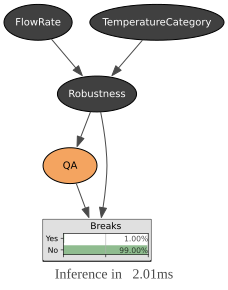

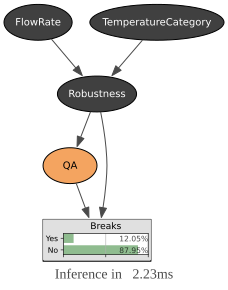

In [136]:
inference_engine = gum.LazyPropagation(bn_fm)

def get_p_break_given_QA(qa_decision):
    inference_engine.setEvidence({"QA": qa_decision})
    inference_engine.makeInference()
    posterior_breaks = inference_engine.posterior(bn_fm.idFromName("Breaks"))
    return posterior_breaks[0] 

p_break_no_QA = get_p_break_given_QA("Fail")  # No qa
p_break_with_QA = get_p_break_given_QA("Pass")  # qa

profit_no_QA = p_break_no_QA * (-10000) + (1 - p_break_no_QA) * 2000
profit_with_QA = p_break_with_QA * (-10000) + (1 - p_break_with_QA) * 2000

print(f"P(Breaks | No QA) = {p_break_no_QA:.4f}")
print(f"P(Breaks | With QA) = {p_break_with_QA:.4f}")
print(f"Profit without QA: £{profit_no_QA:.2f}")
print(f"Profitwith QA: £{profit_with_QA:.2f}")
print('Lisa should remive the QA process as her expected profit is higher without it')


gnb.showInference(bn_fm, evs={"QA": "Fail"}, targets=["Breaks"])
gnb.showInference(bn_fm, evs={"QA": "Pass"}, targets=["Breaks"])


### 4c)
**lisas profits with a low flow rate**

I calculate the effect of restricting production to low flow rate on Lisa’s expected profit. Using Bayesian inference, I determined p(Breaks | QA, Low Flow) for both passing and failing QA. I then computed the expected profit under these conditions and compared it to the original scenario. The results showed the profit improvement per product.


In [138]:
inference_engine = gum.LazyPropagation(bn_fm)

def get_p_break_given_QA_and_low_flow(qa_decision):
    inference_engine.setEvidence({"QA": qa_decision, "FlowRate": "Low"})
    inference_engine.makeInference()
    posterior_breaks = inference_engine.posterior(bn_fm.idFromName("Breaks"))
    return posterior_breaks[0]  # P(Breaks = Yes)

p_break_low_flow_no_QA = get_p_break_given_QA_and_low_flow("Fail")  #lowflow fail qa
p_break_low_flow_with_QA = get_p_break_given_QA_and_low_flow("Pass")  # Low flow and also use QA
profit_low_flow_no_QA = p_break_low_flow_no_QA * (-10000) + (1 - p_break_low_flow_no_QA) * 2000
profit_low_flow_with_QA = p_break_low_flow_with_QA * (-10000) + (1 - p_break_low_flow_with_QA) * 2000

improvement_no_QA = profit_low_flow_no_QA - profit_no_QA  # Profit change if QA is dropped
improvement_with_QA = profit_low_flow_with_QA - profit_with_QA  # Profit change if QA is kept

print(f"P(Breaks | No QA, Low Flow) = {p_break_low_flow_no_QA:.4f}")
print(f"P(Breaks | With QA, Low Flow) = {p_break_low_flow_with_QA:.4f}")
print(f"Expected Profit Without QA (Low Flow) = £{profit_low_flow_no_QA:.2f}")
print(f"Expected Profit With QA (Low Flow) = £{profit_low_flow_with_QA:.2f}")
print(f"Improvement in Profit Without QA: £{improvement_no_QA:.2f} per product")
print(f"Improvement in Profit With QA: £{improvement_with_QA:.2f} per product")


P(Breaks | No QA, Low Flow) = 0.0100
P(Breaks | With QA, Low Flow) = 0.1889
Expected Profit Without QA (Low Flow) = £1880.00
Expected Profit With QA (Low Flow) = £-267.05
Improvement in Profit Without QA: £0.00 per product
Improvement in Profit With QA: £-820.80 per product


**I visualise the process of a low flow rate and the value of the improvement**

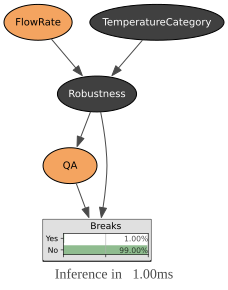

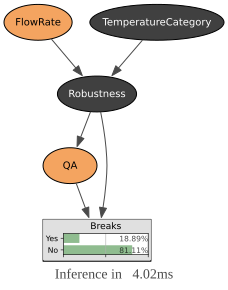

In [140]:
gnb.showInference(bn_fm, evs={"FlowRate": "Low", "QA": "Fail"}, targets=["Breaks"])
gnb.showInference(bn_fm, evs={"FlowRate": "Low", "QA": "Pass"}, targets=["Breaks"])


### 4d)
I analyzed the value of temperature data in Lisa’s decision-making by computing p(Breaks | QA, FlowRate=Low, TemperatureCategory) for each temperature category. Using these probabilities, I calculated the expected profit for different selective QA strategies. Comparing these to the baseline profit with QA for all temperatures, I determined the best strategy and the value of having temperature data per product.  


In [142]:
inference_engine = gum.LazyPropagation(bn_fm)

def get_p_break_given_QA_temp(qa_decision, temp_category):
    inference_engine.setEvidence({"QA": qa_decision, "FlowRate": "Low", "TemperatureCategory": temp_category})
    inference_engine.makeInference()      # P(Breaks) Given QA, FlowRate=Low, and TemperatureCategory
    posterior_breaks = inference_engine.posterior(bn_fm.idFromName("Breaks"))
    return posterior_breaks[0]  # P(Breaks = Yes)

p_break_low_temp_with_QA = get_p_break_given_QA_temp("Pass", "Low")
p_break_med_temp_with_QA = get_p_break_given_QA_temp("Pass", "Medium")
p_break_high_temp_with_QA = get_p_break_given_QA_temp("Pass", "High")  # P(Breaks | QA, FlowRate=Low) per temp cat 

sale_price = 2000
compensation = 10000

profit_QA_all = profit_low_flow_with_QA  # baseline Already Computed in 4c
profit_QA_low = (1 - p_break_low_temp_with_QA) * sale_price - (p_break_low_temp_with_QA * compensation)  #low
profit_QA_med = (1 - p_break_med_temp_with_QA) * sale_price - (p_break_med_temp_with_QA * compensation)  # medium
profit_QA_high = (1 - p_break_high_temp_with_QA) * sale_price - (p_break_high_temp_with_QA * compensation)   #high

best_selective_QA_profit = max(profit_QA_low, profit_QA_med, profit_QA_high)
value_of_temp_data = best_selective_QA_profit - profit_QA_all 

print(f"P(Breaks | QA, Low Temp) = {p_break_low_temp_with_QA:.4f}")
print(f"P(Breaks | QA, Medium Temp) = {p_break_med_temp_with_QA:.4f}")
print(f"P(Breaks | QA, High Temp) = {p_break_high_temp_with_QA:.4f}")

print(f"Profit with QA for all temperatures = £{profit_QA_all:.2f}")
print(f"Profit with QA for only Low Temp = £{profit_QA_low:.2f}")
print(f"Profit with QA for only Medium Temp = £{profit_QA_med:.2f}")
print(f"Profit with QA for only High Temp = £{profit_QA_high:.2f}")

print(f"Best Selective QA Strategy Profit = £{best_selective_QA_profit:.2f}")
print(f"Value of Temperature Data for Lisa = £{value_of_temp_data:.2f} per product")


P(Breaks | QA, Low Temp) = 0.0550
P(Breaks | QA, Medium Temp) = 0.2327
P(Breaks | QA, High Temp) = 0.4780
Profit with QA for all temperatures = £-267.05
Profit with QA for only Low Temp = £1340.00
Profit with QA for only Medium Temp = £-792.83
Profit with QA for only High Temp = £-3735.53
Best Selective QA Strategy Profit = £1340.00
Value of Temperature Data for Lisa = £1607.05 per product


# Question 5

### 5a)  **Bayes network for drug effectiveness**

I constructed a Bayesian network to model drug effectiveness based on diagnosis timing. The network has three variables: Discovery (early or late), Drug (A or B), and Recovery (yes or no). Arcs represent dependencies, where diagnosis timing influences drug choice and recovery, and the prescribed drug also affects recovery. I visualized the structure using pyAgrum.  


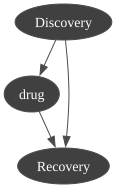

In [145]:
bn_drugs = gum.BayesNet("DrugEffectiveness")

discovery = bn_drugs.add(gum.LabelizedVariable("Discovery", " Discovery Interval", ["Early", "Late"]))
drug = bn_drugs.add(gum.LabelizedVariable("drug", "Drug prescribed", ["A", "B"]))
recovery = bn_drugs.add(gum.LabelizedVariable("Recovery", "Patient Recovery", ["No", "Yes"]))

bn_drugs.addArc(discovery, drug)       
bn_drugs.addArc(discovery, recovery)   
bn_drugs.addArc(drug, recovery)        

gnb.showBN(bn_drugs)


### **conditional probability table**

In [147]:
bn_drugs.cpt(discovery).fillWith([0.6, 0.4])  # 60% early, 40% late

# P(drug | discovery)
bn_drugs.cpt(drug)[{"Discovery": "Early"}] = [0.9, 0.1]  # 90% A, 10% B earky
bn_drugs.cpt(drug)[{"Discovery": "Late"}] = [0.4, 0.6]   # 40% A, 60% B late

bn_drugs.cpt(recovery).fillWith([0.8, 0.2, 0.9, 0.1, 0.5, 0.5, 0.6, 0.4 ]) # P(Recovery | discovery, drug)


(pyAgrum.Potential@00000198CE3F0960) 
             ||  Recovery         |
Discov|drug  ||No       |Yes      |
------|------||---------|---------|
Early |A     || 0.8000  | 0.2000  |
Late  |A     || 0.9000  | 0.1000  |
Early |B     || 0.5000  | 0.5000  |
Late  |B     || 0.6000  | 0.4000  |

### 5b)
**I calculate the absolute risk of not recovering from each drug**

I manually calculated the absolute risk of not recovering for each drug by first determining the joint probability of not recovering and receiving each drug, considering both early and late diagnoses. I then normalized these values by the probability of receiving each drug to obtain p(Not Recover | A) and p(Not Recover | B) providing a clear comparison of the risks associated with each drug.  


In [149]:
#p(early diagnosos)

prob_early = 0.6
prob_late = 0.4

# cond prob of getting drug given timing of diagnosis

prob_a_early = 0.9
prob_b_early = 0.1
prob_a_late = 0.4
prob_b_late = 0.6

prob_recover_a_early = 0.8
prob_recover_a_late = 0.5              # recovery given drug and diagnosis timing
prob_recover_b_early = 0.9
prob_recover_b_late = 0.6
prob_not_a_early = 1 - prob_recover_a_early
prob_not_a_late = 1 - prob_recover_a_late
prob_not_b_early = 1 - prob_recover_b_early
prob_not_b_late = 1 - prob_recover_b_late

p_notrecover_and_a = (prob_not_a_early * prob_a_early * prob_early) + (prob_not_a_late * prob_a_late * prob_late)
p_notrecover_and_b = (prob_not_b_early * prob_b_early * prob_early) + (prob_not_b_late * prob_b_late * prob_late)

p_a = (prob_a_early * prob_early) + (prob_a_late * prob_late)
p_b = (prob_b_early * prob_early) + (prob_b_late * prob_late)

p_notrecover_given_a = p_notrecover_and_a / p_a
p_notrecover_given_b = p_notrecover_and_b / p_b

print(f" The absolute risk of not recovering with drug A is {p_notrecover_given_a:.2%}")
print(f" The absolute risk of not recovering with drug B is {p_notrecover_given_b:.2%}")



 The absolute risk of not recovering with drug A is 26.86%
 The absolute risk of not recovering with drug B is 34.00%


### 5c)
**Doctors conclusions**

The doctor is incorrect with his conclusions that drug A is more affective in comparison to drug B. Upon late diagnosis, drug B performs better by 10% at a rate of 60% in comparison to drug A which is effective 50% of the time. Drug B also performs 10% better than drug A at a rate of 90% in comparison to 80% for drug B.

Interestingly, drug B performs better in both early and late diagnosis however the doctor still concludes drug A has superior performance when comparing the two drugs. It is likely the doctor assumes since it is recieved more by patients in during early diagnosis (90%) this thereby suggests drug A is the most effective however this simply increases the overall recovery rate for drug A simply due to larger numbers. 

This is known as the simpsons paradox, where aggregated data can mislead us due to the differences in group distributions. In this scenario, the skewed nature of the overall recovery rates by the assignment of patients to a drug is shown than the actual effectiveness of the drugs themselves.